In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision.datasets import MNIST
from torchvision import transforms
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt

device ="cuda" if torch.cuda.is_available() else "cpu"
print("Using Device", device)

Using Device cpu


In [3]:
transform =transforms.ToTensor()

train_data=MNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)
test_data=MNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

train_loader=DataLoader(
    train_data,
    batch_size=64,
    shuffle=True
)
test_loader=DataLoader(
    test_data,
    batch_size=64,
    shuffle=False
)

100.0%
100.0%
100.0%
100.0%


In [5]:
class digitmodel(nn.Module):
    def __init__(self):
        super().__init__()


        self.net=nn.Sequential(
            nn.Linear(28*28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),

            nn.Linear(64,10)
        )
    def forward(self, x):
        return self.net(x)

Epoch 1/5 | Loss: 318.3396
Epoch 2/5 | Loss: 132.2565
Epoch 3/5 | Loss: 90.8249
Epoch 4/5 | Loss: 68.7922
Epoch 5/5 | Loss: 52.9129
Total Accuracy: 97.46%
Model saved as mnist_model.pth 


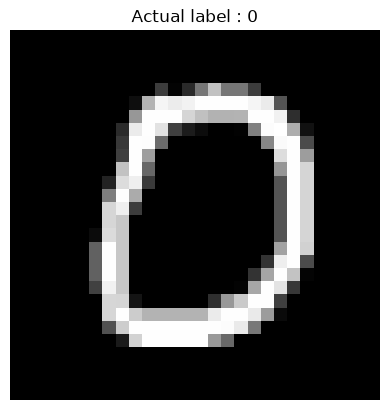

User picked image index 10
Actual Label 0
Model Prediction 0


In [14]:
model = digitmodel().to(device)

loss_fn=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters(), lr=0.001)

epochs=5

for epoch in range(epochs):
    model.train()
    total_loss=0

    for images, labels in train_loader:
        images=images.view(images.size(0),-1).to(device)
        labels=labels.to(device)

        optimizer.zero_grad()
        outputs= model(images)
        loss=loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss+=loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

model.eval()
correct=0
total=0

with torch.no_grad():
     for images, labels in test_loader:
            images=images.view(images.size(0), -1).to(device)
            labels=labels.to(device)

            outputs= model(images)
            predictions=outputs.argmax(dim=1)
            
            correct+=(predictions == labels).sum().item()
            total+=labels.size(0)
accuracy=100* correct/total
print(f"Total Accuracy: {accuracy:.2f}%")


torch.save(model.state_dict(), "mnist_model.pth")
print("Model saved as mnist_model.pth ")

index=10
image, true_label = test_data[index]
plt.imshow(image.squeeze(), cmap="gray")
plt.title(f"Actual label : {true_label}")
plt.axis("off")
plt.show()


image_flat= image.view(1,-1).to(device)

with torch.no_grad():
     output = model(image_flat)
     predicted_label= output.argmax(dim=1).item()


print("User picked image index", index)
print("Actual Label", true_label)
print("Model Prediction", predicted_label)